In [90]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [91]:
df = pd.read_csv('/kaggle/input/datasets/sanjanbm/modified-titanic-data/train.csv',usecols=['Age','Fare','Survived'])

In [92]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [94]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [95]:
# 1. Force the column back to numbers. 
# 'coerce' turns those accidental "methods" into NaN (Not a Number)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# 2. Now fill the NaNs properly using the RESULT of the mean calculation
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 3. NOW you can safely convert to int
df['Age'] = df['Age'].astype(int)

# 4. Check the result
print(df['Age'].head())

0    22
1    38
2    26
3    35
4    35
Name: Age, dtype: int64


In [96]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [97]:
X =  df.drop(columns=['Survived'])
y = df['Survived']

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

/tmp/ipykernel_55/2981780686.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


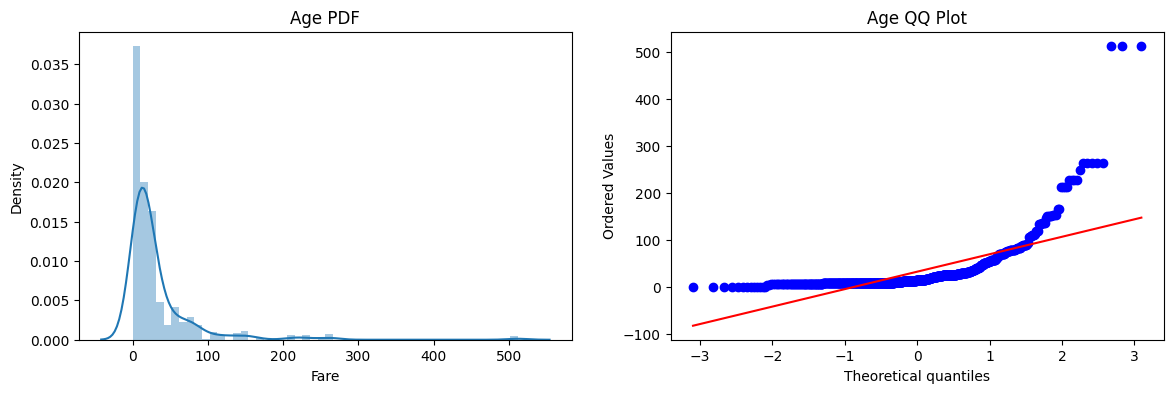

In [99]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [100]:
def plot_data(df, column):
    plt.figure(figsize=(14, 4))
    
    # Histogram / PDF
    plt.subplot(121)
    sns.histplot(df[column], kde=True, color='blue')
    plt.title(f'{column} Distribution')
    
    # QQ-Plot
    plt.subplot(122)
    stats.probplot(df[column], dist="norm", plot=plt)
    plt.title(f'{column} QQ Plot')
    plt.show()

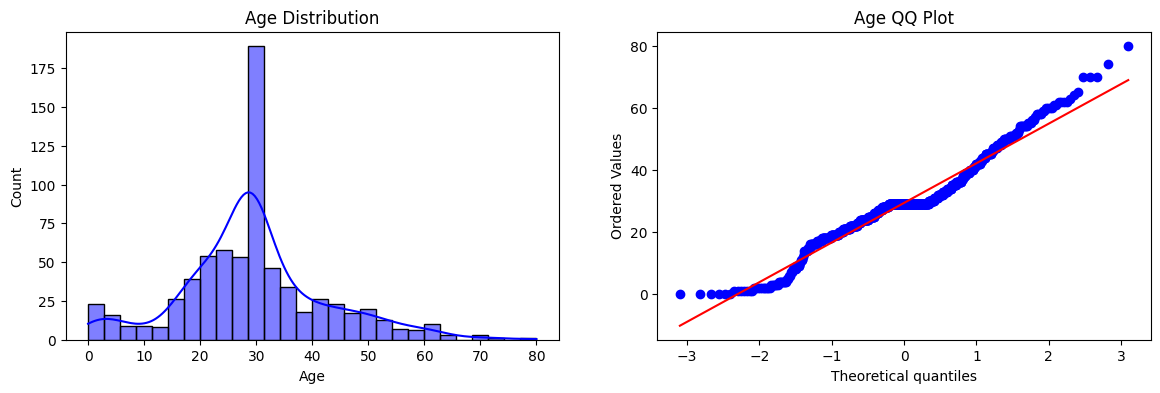

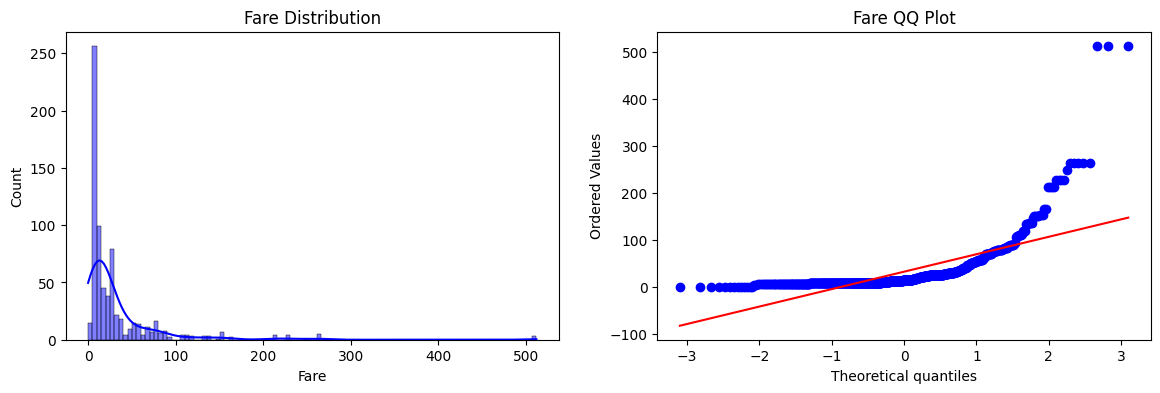

In [101]:
plot_data(X_train, 'Age')
plot_data(X_train, 'Fare')

In [102]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [103]:
X_train.isnull().sum()

Age     0
Fare    0
dtype: int64

In [104]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6480446927374302
Accuracy DT 0.664804469273743


## Log Transform

In [105]:
trf = FunctionTransformer(func=np.log1p)

In [106]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [109]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268


In [112]:
# For complete dataset usign CV

X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('Lr', np.mean(cross_val_score(clf, X_transformed, y, cv = 10,scoring='accuracy')))
print('DT', np.mean(cross_val_score(clf2, X_transformed, y, cv = 10,scoring='accuracy')))

Lr 0.678027465667915
DT 0.6610736579275905


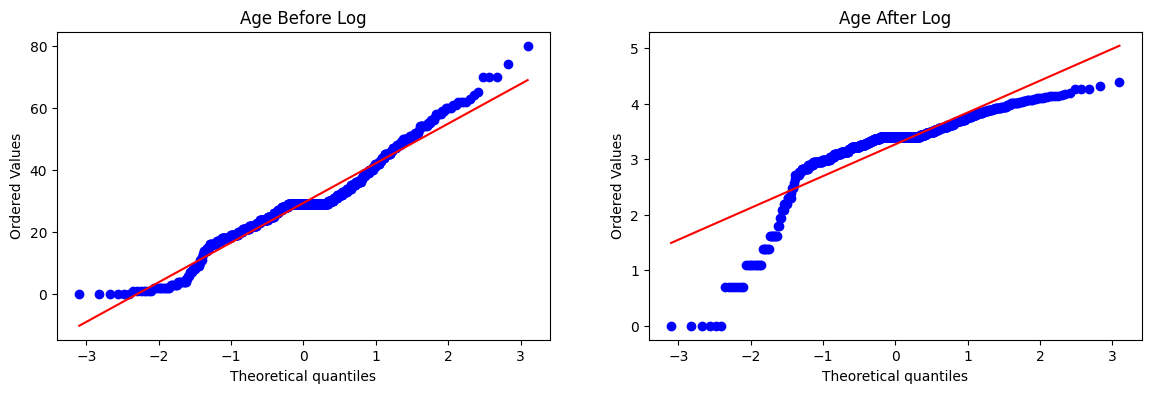

In [114]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

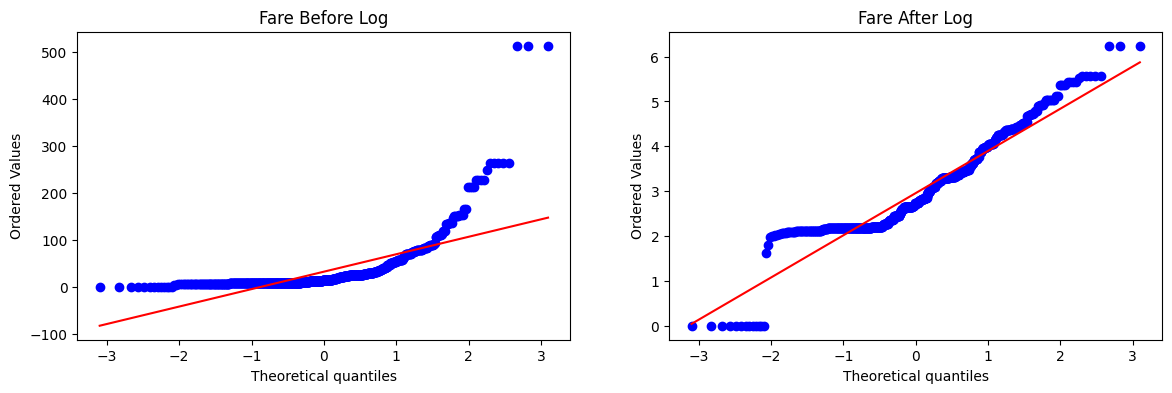

In [113]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

In [115]:
trf2 = ColumnTransformer([
    ('log',FunctionTransformer(np.log1p),['Fare'])
],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [116]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.664804469273743


In [117]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6610611735330836


In [118]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6589013732833957


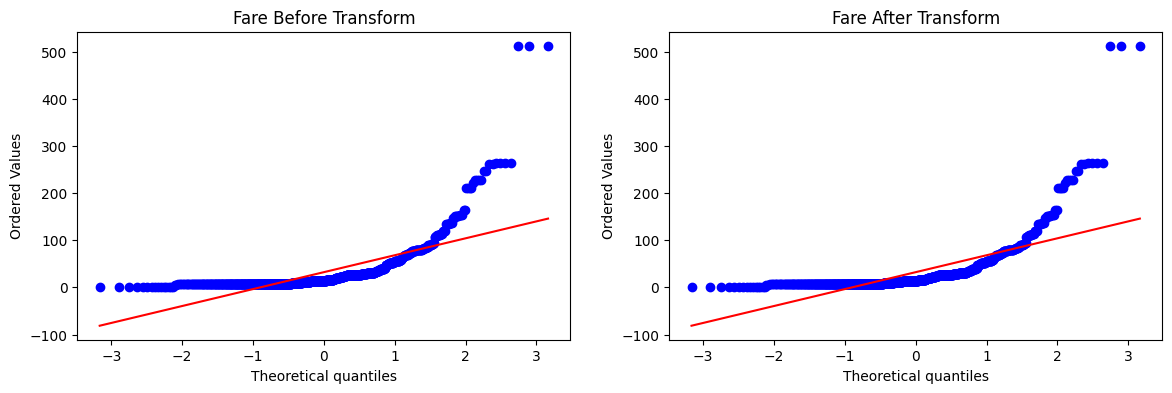

In [120]:
apply_transform(lambda x:x)

Accuracy 0.6420099875156055


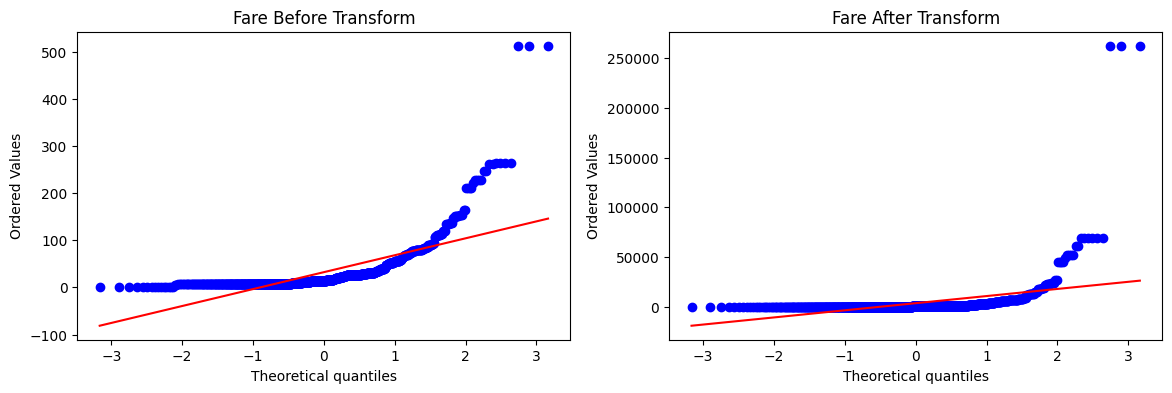

In [121]:
apply_transform(lambda x:x**2)

Accuracy 0.6589013732833957


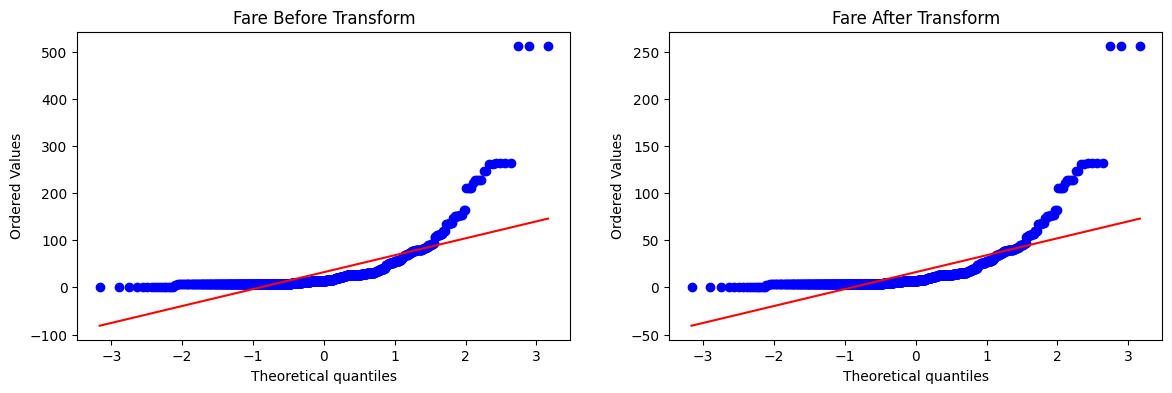

In [122]:
apply_transform(lambda x:x**1/2)

Accuracy 0.61729088639201


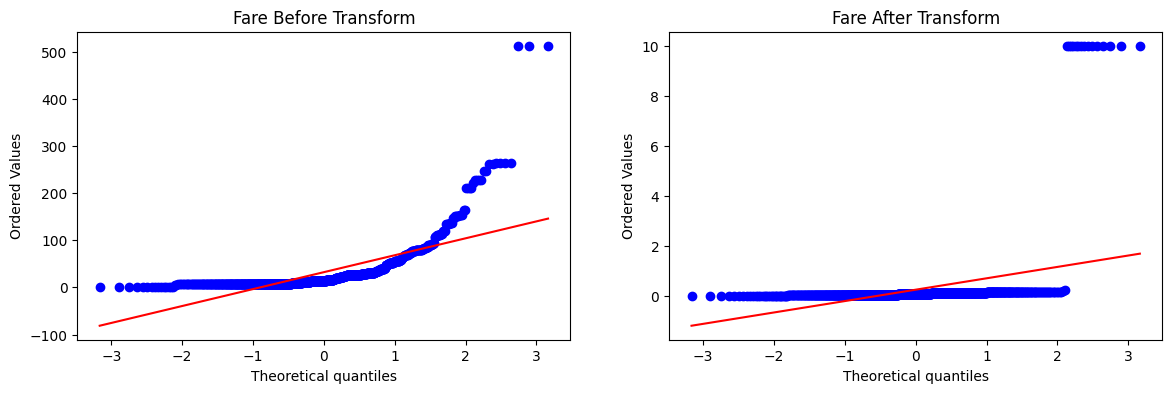

In [124]:
apply_transform(lambda x:1/(x+0.1))

Accuracy 0.6217602996254681


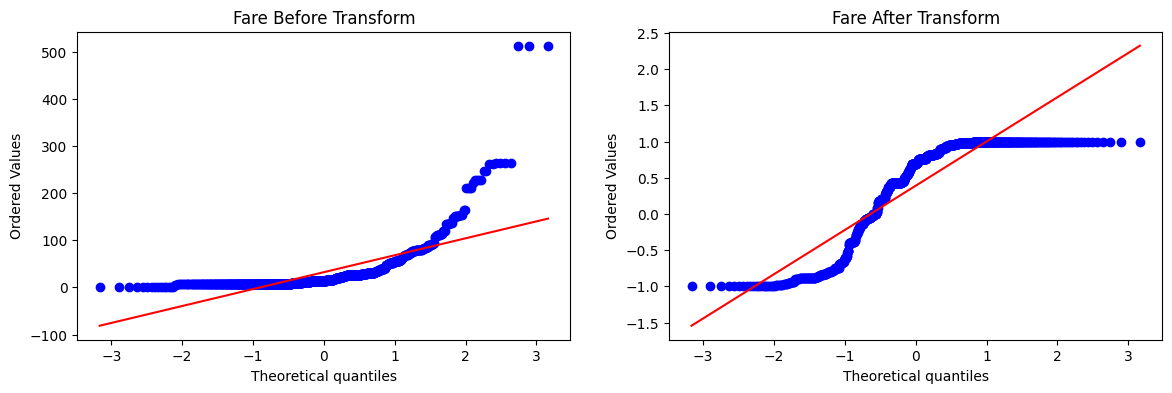

In [119]:
apply_transform(np.sin)

Accuracy 0.61729088639201


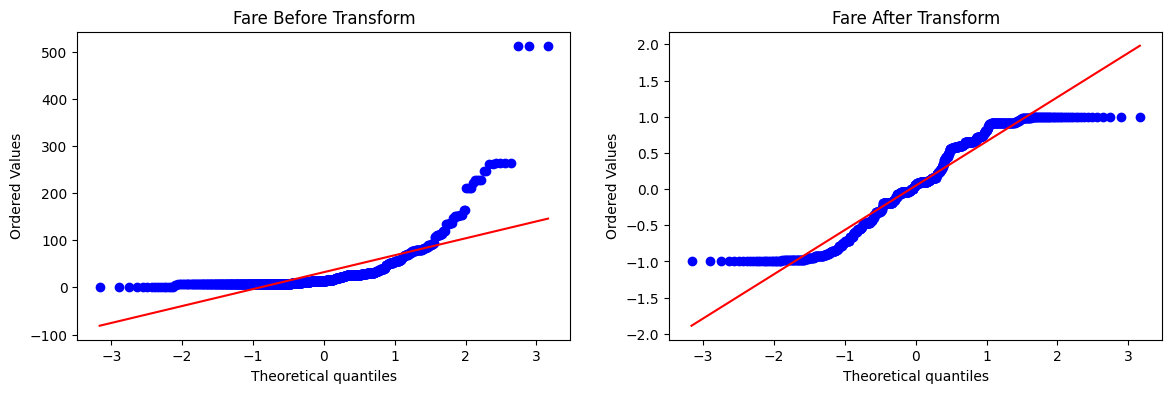

In [125]:
apply_transform(np.cos)